# YOLOv8 Training

## 1. Initial Setup

In [1]:
!pip install -q ultralytics
%matplotlib inline

import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

YAML_PATH = "/home/sagemaker-user/Kitchen_Eye/data/Dataset/dataset.yaml"
SAVE_DIR = "/home/sagemaker-user/Kitchen_Eye/training_models/yolov8"

print("Setup complete.")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
amazon-sagemaker-jupyter-ai-q-developer 1.2.9 requires numpy<=2.0.1, but you have numpy 2.4.4 which is incompatible.
amazon-sagemaker-sql-magic 0.1.4 requires numpy<2, but you have numpy 2.4.4 which is incompatible.
autogluon-common 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.4.4 which is incompatible.
autogluon-core 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.4.4 which is incompatible.
autogluon-features 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have 

## 2. Model Traing

#### Initial check if training works

In [2]:
# Just for checkinng (epochs=3, batch=-1)
# model = YOLO('yolov8s.pt')  

# results = model.train(
#     data=YAML_PATH,
#     epochs=3,
#     patience=50,
#     seed=42,
#     imgsz=640,
#     batch=-1,
#     freeze=0,   
#     save=True, 
#     project=SAVE_DIR,
#     name='train_run',
#     exist_ok=True
#     verbose=False
# )

#### Training with epochs=300

In [ ]:
model = YOLO('yolov8s.pt')  # COCO-pretrained model

results = model.train(
    data=YAML_PATH,
    epochs=300,
    patience=50,
    seed=42,
    imgsz=640,
    batch=16,
    freeze=0,  # Full fine-tuning (unfreeze all layers)
    save=True, # Auto-save best & last
    project=SAVE_DIR,
    name='train_run',
    exist_ok=True, # Overwrite the existing "train_run" directory (Not create "train_run2", ...)
    verbose=False  # Quiet logs
)

Ultralytics 8.4.46 🚀 Python-3.12.9 torch-2.6.0 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/sagemaker-user/Kitchen_Eye/data/Dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

2026/05/02 00:27:19 INFO mlflow.tracking.fluent: Experiment with name '/home/sagemaker-user/Kitchen_Eye/training_models/yolov8' does not exist. Creating a new experiment.


MLflow: logging run_id(3dfec1f28d5b476e9d5b9c41e5b5e736) to runs/mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs/mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to /home/sagemaker-user/Kitchen_Eye/training_models/yolov8/train_run
Starting training for 300 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/300       3.7G      1.054      1.273      1.304        230        640: 100% ━━━━━━━━━━━━ 456/456 2.3it/s 3:18<0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 2.5it/s 19.4s0.4s
                   all       1563      11209        0.9      0.889      0.936       0.72

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/300      4.13G     0.8678     0.6413      1.135        160        640: 100% ━━━━━━━━━━━━ 456/456 2

## 3. Model Testing & Evaluation

Loaded the best model from: /home/sagemaker-user/Kitchen_Eye/training_models/yolov8/train_run/weights/best.pt

Evaluating on Train Set...
Ultralytics 8.4.47 🚀 Python-3.12.9 torch-2.6.0 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2992.0±1677.7 MB/s, size: 373.4 KB)
val: Scanning /home/sagemaker-user/Kitchen_Eye/data/split_dataset/train/labels.cache... 7291 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 7291/7291 2.5Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 456/456 7.0it/s 1:05<0.2ss
                   all       7291      51962      0.998      0.998      0.995      0.979
Speed: 0.5ms preprocess, 4.6ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /home/sagemaker-user/Kitchen_Eye/training_models/yolov8/eval_train

Evaluating on Validation Set...
Ultralytics 8.4.47 🚀 Python

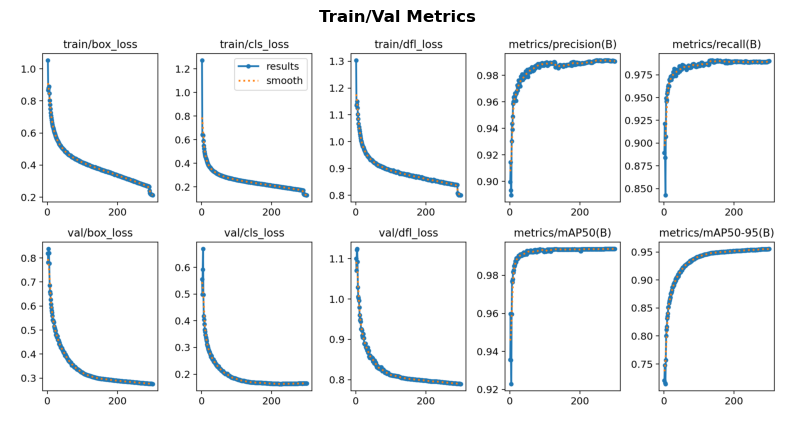

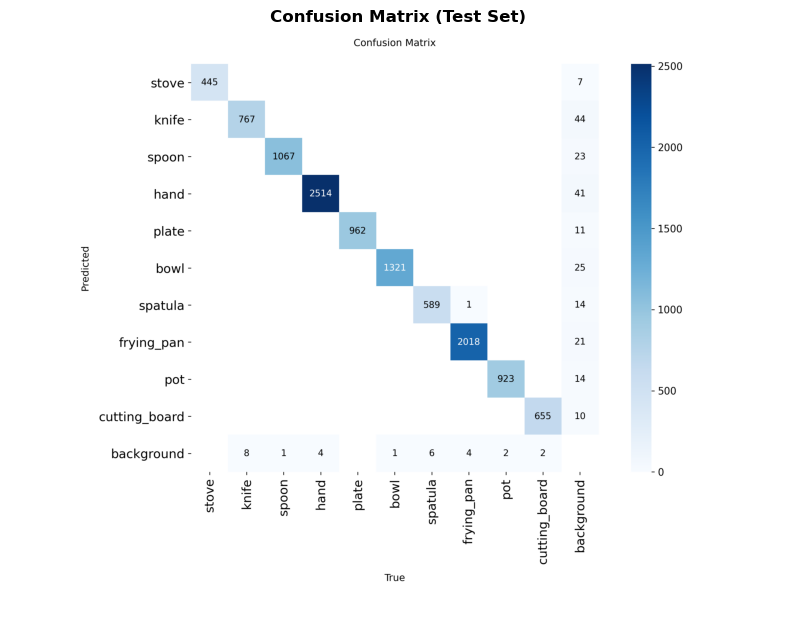

In [3]:
# Performance Summary
BEST_MODEL_PATH = os.path.join(SAVE_DIR, 'train_run/weights/best.pt')
best_model = YOLO(BEST_MODEL_PATH)
print(f"Loaded the best model from: {BEST_MODEL_PATH}")

common_eval_args = {
    'data': YAML_PATH,
    'project': SAVE_DIR,
    'exist_ok': True,
    'verbose': False
}
print("\nEvaluating on Train Set...")
results_train = best_model.val(split='train', name='eval_train', **common_eval_args)

print("\nEvaluating on Validation Set...")
results_val = best_model.val(split='val', name='eval_val', **common_eval_args)

print("\nEvaluating on Test Set...")
results_test = best_model.val(split='test', name='eval_test', **common_eval_args)

print("\n" + "="*45)
print(" PERFORMANCE METRICS (mAP50-95 / mAP50)")
print("="*45)
print(f"Train Set:         {results_train.box.map:.4f} / {results_train.box.map50:.4f}")
print(f"Validation Set:    {results_val.box.map:.4f} / {results_val.box.map50:.4f}")
print(f"Test Set:          {results_test.box.map:.4f} / {results_test.box.map50:.4f}")
print("="*45)

# Result Visualization
def show_yolo_plot(run_name, filename, title):
    path = os.path.join(SAVE_DIR, run_name, filename)
    if os.path.exists(path):
        img = plt.imread(path)
        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.title(title, fontsize=12, fontweight='bold')
        plt.axis('off')
        plt.show()
    else:
        print(f"Warning: {filename} not found at {path}")

show_yolo_plot('train_run', 'results.png', 'Train/Val Metrics')
show_yolo_plot('eval_test', 'confusion_matrix.png', 'Confusion Matrix (Test Set)')

## 4. Model Prediction Samples

Running inference on 6 unseen test images...


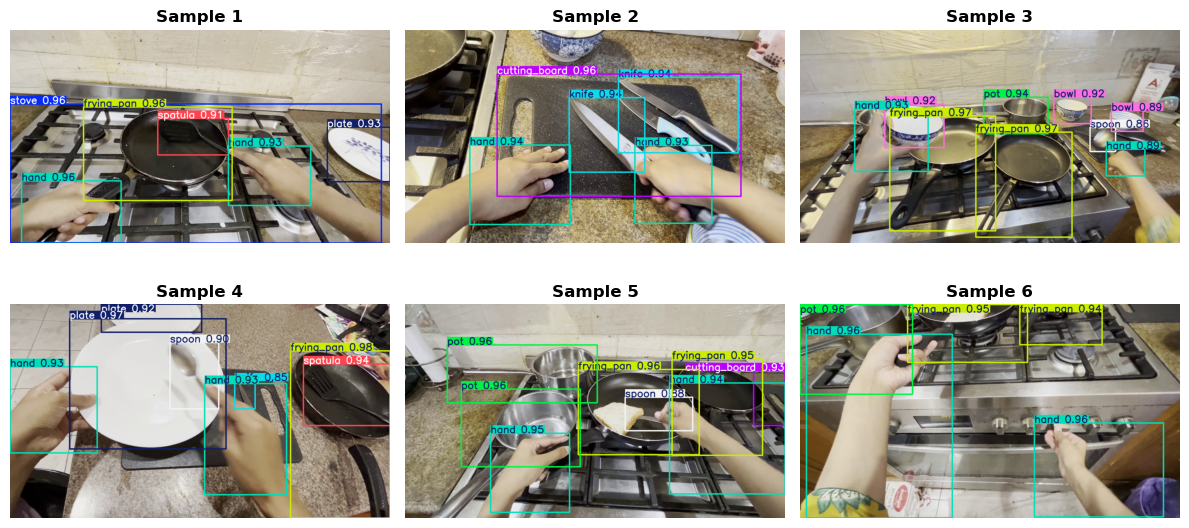

In [9]:
# Select test images
TEST_IMG_DIR = "/home/sagemaker-user/Kitchen_Eye/data/split_dataset/test/images"
all_test_imgs = sorted([
    os.path.join(TEST_IMG_DIR, f)
    for f in os.listdir(TEST_IMG_DIR)
    if f.lower().endswith('.jpg')
])
random.seed(SEED)
sample_images = random.sample(all_test_imgs, 6)

# Run Inference
print(f"Running inference on {len(sample_images)} unseen test images...")
results_predict = best_model.predict(
    source=sample_images,
    conf=0.25,
    iou=0.5,
    save=False,
    verbose=False
)

# Visualize predictions
cols = 3
rows = (6 + cols - 1) // cols
plt.figure(figsize=(12, 3 * rows))

for i, r in enumerate(results_predict):
    img_bgr = r.plot()
    img_rgb = img_bgr[..., ::-1]

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Sample {i + 1}", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Layer Check

In [3]:
!pip install -q ultralytics
from ultralytics import YOLO

model = YOLO('yolov8s.pt')
model.info(detailed=True)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
amazon-sagemaker-jupyter-ai-q-developer 1.2.9 requires numpy<=2.0.1, but you have numpy 2.4.4 which is incompatible.
amazon-sagemaker-sql-magic 0.1.4 requires numpy<2, but you have numpy 2.4.4 which is incompatible.
autogluon-common 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.4.4 which is incompatible.
autogluon-core 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.4.4 which is incompatible.
autogluon-features 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have 

(129, 11166560, 0, 28.816844800000002)

In [4]:
print(model.model)

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
    